# Factoring 15

In [1]:
import numpy as np
from math import gcd
from fractions import Fraction

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

# Setting

In [2]:
N = 15
a = 2

L_target = 4 # The target register needs 4 qubits because 15 < 2^4
L_count = 8 # Number of counting qubits for phase precision
Q = 2**L_count

In [3]:
def u2mod15():
    """
    Modular multiplication by 2 modulo 15.

    This gate implements

        U_2 |x> = |2x mod 15>

    on a 4-qubit target register.
    """
    U = QuantumCircuit(4, name="U_2")

    U.swap(2, 3)
    U.swap(1, 2)
    U.swap(0, 1)

    return U.to_gate()

In [4]:
def u4mod15():
    """
    Modular multiplication by 4 modulo 15.

    This gate implements

        U_4 |x> = |4x mod 15>

    on a 4-qubit target register.
    """
    U = QuantumCircuit(4, name="U_4")

    U.swap(1, 3)
    U.swap(0, 2)

    return U.to_gate()


def a2kmodN(a: int, k: int, N: int) -> int:
    """
    Compute a^{2^k} mod N by repeated squaring.
    """
    for _ in range(k):
        a = int(np.mod(a**2, N))
    return a

## Construct the quantum order-finding circuit used in Shor's algorithm

In [5]:
counting = list(range(L_count))
target = list(range(L_count, L_count + L_target))

In [6]:
qc = QuantumCircuit(L_count + L_target, L_count)

# Initialize the target register to |1>
qc.x(target[0])
qc.barrier()

# Put the counting register into a uniform superposition
qc.h(counting)
qc.barrier()

# Apply controlled-U^(2^j), where U|y> = |a*y mod N>
for j in range(L_count):
    c = pow(base=a, exp=(2**j), mod=N)

    if c == 1:
        # M_1 is the identity, so no gate is needed.
        pass
    elif c == 2:
        u = u2mod15().control(1, annotated=False)
        qc.append(u, [counting[j]] + target)

    elif c == 4:
        u = u4mod15().control(1, annotated=False)
        qc.append(u, [counting[j]] + target)
    else:
        raise ValueError(f"No SWAP-based implementation is defined for M_{c}.")

qc.barrier()

# Apply the inverse QFT to extract the phase information
qc.append(QFTGate(L_count).inverse(annotated=True), counting)
qc.barrier()

# Measure the counting register
qc.measure(counting, counting)

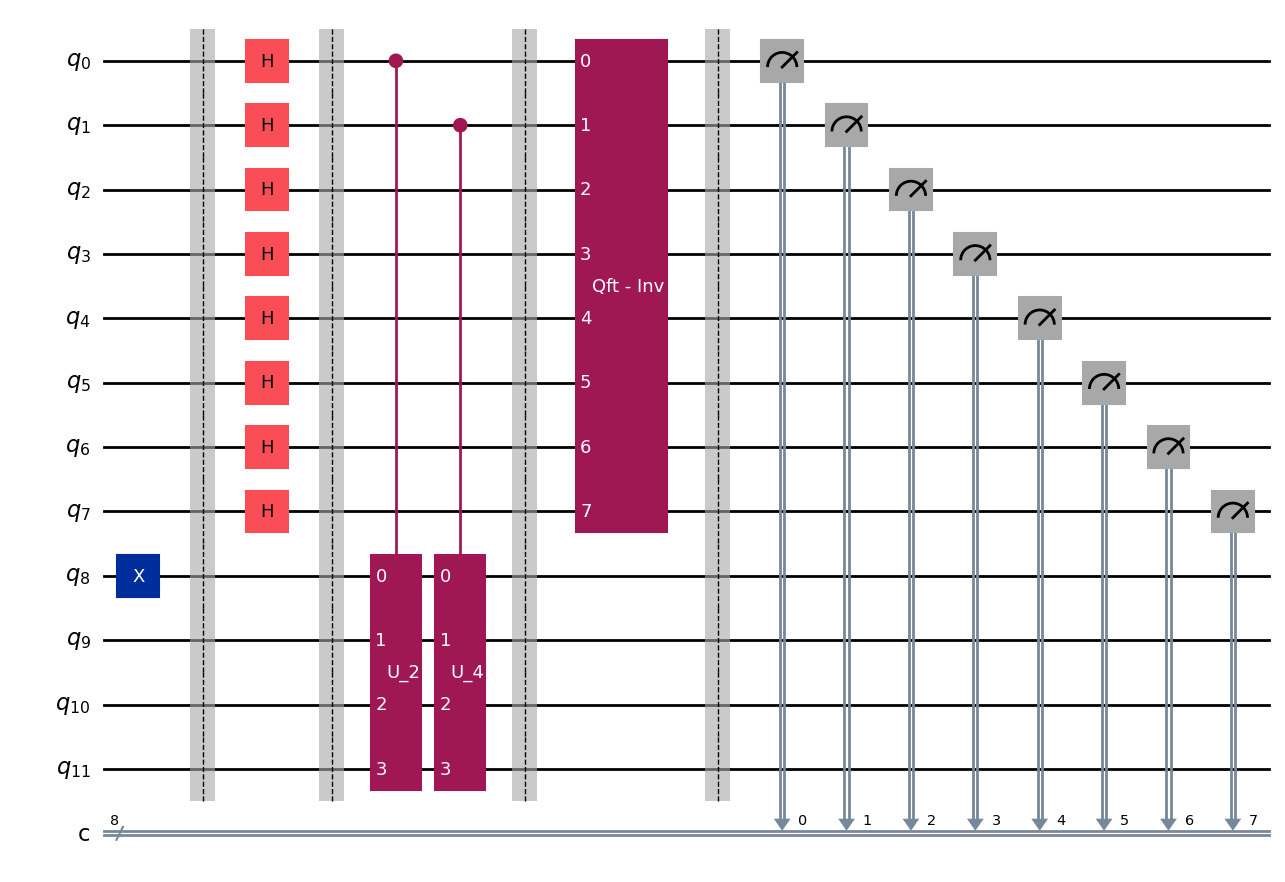

In [7]:
qc.draw(output='mpl')

In [8]:
simulator = AerSimulator()

In [9]:
pass_manager = generate_preset_pass_manager(backend=simulator, optimization_level=1)

In [10]:
transpiled_qc = pass_manager.run(qc)

In [11]:
# transpiled_qc.draw(output='text')

In [12]:
job = simulator.run(transpiled_qc, shots=2048, seed_simulator=1234)

In [13]:
result = job.result()

In [14]:
counts = result.get_counts()

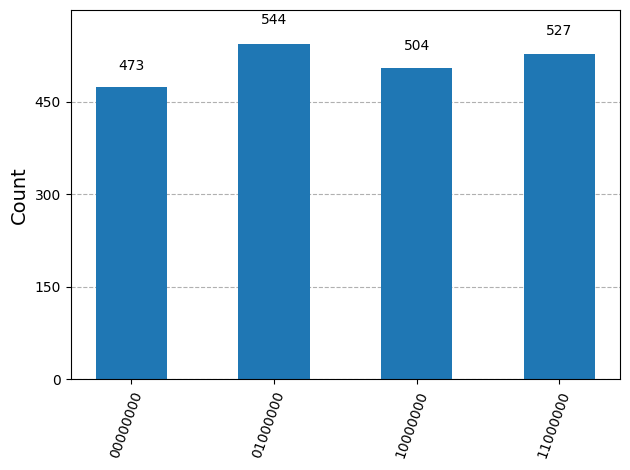

In [15]:
plot_histogram(counts)

# Postprocess
Use continued fractions and gcd computations to extract the factors

In [16]:
print("Measured candidates:")
for bitstring, shots in sorted(counts.items(), key=lambda kv: kv[1], reverse=True):
    m = int(bitstring, base=2)
    # Continued-fraction-based rational approximation
    phase = Fraction(m, Q).limit_denominator(N)
    # Candidate order
    r = phase.denominator

    print(
        f"  bitstring={bitstring}, shots={shots:4d}, "
        f"m={m:3d}, phase≈{phase}, candidate r={r}"
    )

    # Skip the trivial phase
    if phase.numerator == 0:
        continue

    # The order must be even for the standard factor extraction step
    if r % 2 != 0:
        continue

    # Check that r is a valid order candidate
    if pow(a, r, N) != 1:
        continue

    x = pow(a, r // 2, N)

    # If x = -1 mod N, this attempt does not give non-trivial factors
    if x == N - 1:
        continue

    # Extract non-trivial factors using gcd
    p = gcd(x - 1, N)
    q = gcd(x + 1, N)

    if 1 < p < N and 1 < q < N:
        print(f"🙌 phase={phase} --> {r=}")
        print(f"🙌 {N=} --> {p=} & {q=}")
        break
else:
    print("😱 No non-trivial factor found. Try more shots or rerun.")

Measured candidates:
  bitstring=01000000, shots= 544, m= 64, phase≈1/4, candidate r=4
🙌 phase=1/4 --> r=4
🙌 N=15 --> p=3 & q=5
